In [ ]:
# --- PARAMETERS ---
WIDTH = 9
HEIGHT = 9
NUM_AGENTS = 4

BATCH_SIZE = 256
HIDDEN_DIM = 512
NUM_LAYERS = 4
LEARNING_RATE = 0.0001
NUM_ITERATIONS = 100000  # 10x more

# File Paths
STATES_FILE_PATH = f"centralized_model{WIDTH}x{HEIGHT}_agents{NUM_AGENTS}/trained_states_centralized.pkl"
MODEL_SAVE_PATH = f"mlp_reward_{WIDTH}x{HEIGHT}_{NUM_AGENTS}a"

DEBUG = False  # Set True for quick test with limited data

In [2]:
import sys
import os
import pickle
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

sys.path.append('../../')
from tadd_helpers.env_functions import State

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Path(MODEL_SAVE_PATH).mkdir(parents=True, exist_ok=True)

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Using device: cuda


In [3]:
def state_to_mlp_input(raw_state: dict, agent_pos) -> np.ndarray:
    """Convert raw state dict to flattened MLP input."""
    agents_map = raw_state["agents"].astype(np.float32)
    apples_map = raw_state["apples"].astype(np.float32)
    height, width = agents_map.shape
    
    # Self map (one-hot)
    self_map = np.zeros((height, width), dtype=np.float32)
    self_map[agent_pos[0], agent_pos[1]] = 1.0
    
    # Others map
    others_map = agents_map - self_map
    
    # Stack and flatten: (3, H, W) -> (3*H*W,)
    return np.stack([apples_map, others_map, self_map], axis=0).flatten()


def get_decentralized_rewards(state: State) -> dict[int, float]:
    """
    New simplified reward:
    - Picker: -1.0
    - Bystander: 2.0 / (N-1)
    - No pick: 0.0
    """
    res = {}
    all_agents = state._agents
    num_agents = len(all_agents)
    
    # Find picker (agent on apple)
    picker_idx = None
    for agent_idx, pos in all_agents.items():
        if state.apples[pos[0], pos[1]] > 0:
            picker_idx = agent_idx
            break
    
    # No pick case
    if picker_idx is None:
        return {idx: 0.0 for idx in all_agents.keys()}
    
    # Pick case
    bystander_reward = 2.0 / (num_agents - 1) if num_agents > 1 else 0.0
    for agent_idx in all_agents.keys():
        res[agent_idx] = -1.0 if agent_idx == picker_idx else bystander_reward
    
    return res

In [4]:
if not os.path.exists(STATES_FILE_PATH):
    raise FileNotFoundError(f"States file not found at {STATES_FILE_PATH}")

with open(STATES_FILE_PATH, "rb") as f:
    states = pickle.load(f)

print(f"Loaded {len(states)} states.")

# Buckets for balanced training
data_zero = []
data_picker = []
data_bystander = []

print("Processing states into buckets...")
states_to_process = states[:2000] if DEBUG else states

for state in tqdm(states_to_process):
    rewards = get_decentralized_rewards(state)
    raw_state = {"agents": state.agents, "apples": state.apples}
    
    for agent_id, r in rewards.items():
        item = (raw_state, state.agent_position(agent_id), r)
        
        if r == 0.0:
            data_zero.append(item)
        elif r == -1.0:
            data_picker.append(item)
        else:
            data_bystander.append(item)

print(f"\nData Distribution:")
print(f"  Zero:      {len(data_zero)}")
print(f"  Picker:    {len(data_picker)}")
print(f"  Bystander: {len(data_bystander)}")

# Free original states
del states

Loaded 800000 states.
Processing states into buckets...


100%|██████████| 800000/800000 [00:09<00:00, 85021.28it/s] 


Data Distribution:
  Zero:      2153188
  Picker:    261703
  Bystander: 785109


In [8]:
print("Verifying data integrity...\n")

for name, bucket in [("ZERO", data_zero), ("PICKER", data_picker), ("BYSTANDER", data_bystander)]:
    # Check 5 random samples
    for i in range(5):
        s, pos, r = random.choice(bucket)
        self_on_apple = s["apples"][pos[0], pos[1]] > 0
        any_agent_on_apple = np.any((s["apples"] > 0) & (s["agents"] > 0))
        
        # Verify expectations
        if name == "ZERO":
            assert not any_agent_on_apple, f"ZERO sample has agent on apple!"
        elif name == "PICKER":
            assert self_on_apple, f"PICKER sample: self NOT on apple!"
        elif name == "BYSTANDER":
            assert not self_on_apple, f"BYSTANDER sample: self IS on apple!"
            assert any_agent_on_apple, f"BYSTANDER sample: no agent on apple!"
    
    print(f"✓ {name}: All checks passed")

print("\n✓ Data integrity verified!")

Verifying data integrity...

✓ ZERO: All checks passed
✓ PICKER: All checks passed
✓ BYSTANDER: All checks passed

✓ Data integrity verified!


In [5]:
class RewardMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

input_dim = 3 * HEIGHT * WIDTH
model = RewardMLP(input_dim, HIDDEN_DIM, NUM_LAYERS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Model initialized. Input dim: {input_dim}")

Model initialized. Input dim: 243


Training for 10000 iterations (balanced 33/33/33 split)...


100%|██████████| 10000/10000 [02:01<00:00, 82.26it/s]


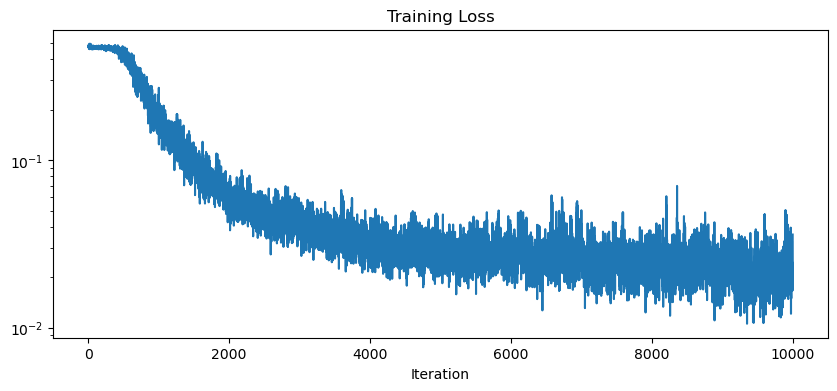

In [6]:
losses = []
n_per_type = BATCH_SIZE // 3

print(f"Training for {NUM_ITERATIONS} iterations (balanced 33/33/33 split)...")

model.train()
for i in tqdm(range(NUM_ITERATIONS)):
    batch_inputs = []
    batch_targets = []
    
    # Sample from each bucket
    for _ in range(n_per_type):
        s, pos, r = random.choice(data_zero)
        batch_inputs.append(state_to_mlp_input(s, pos))
        batch_targets.append(r)
    
    for _ in range(n_per_type):
        s, pos, r = random.choice(data_picker)
        batch_inputs.append(state_to_mlp_input(s, pos))
        batch_targets.append(r)
    
    for _ in range(n_per_type):
        s, pos, r = random.choice(data_bystander)
        batch_inputs.append(state_to_mlp_input(s, pos))
        batch_targets.append(r)
    
    # Train step
    x = torch.tensor(np.stack(batch_inputs), dtype=torch.float32).to(device)
    y = torch.tensor(batch_targets, dtype=torch.float32).to(device)
    
    optimizer.zero_grad()
    preds = model(x).squeeze(1)
    loss = nn.functional.mse_loss(preds, y)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

# Plot
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.yscale('log')
plt.title("Training Loss")
plt.xlabel("Iteration")
plt.show()

In [7]:
model.eval()
bystander_target = 2.0 / (NUM_AGENTS - 1)

def evaluate_bucket(data, name, target_val):
    if not data:
        return
    
    sample = random.sample(data, min(5000, len(data)))
    inputs = [state_to_mlp_input(s, pos) for s, pos, r in sample]
    targets = np.array([r for s, pos, r in sample])
    
    x = torch.tensor(np.stack(inputs), dtype=torch.float32).to(device)
    
    with torch.no_grad():
        preds = model(x).squeeze(1).cpu().numpy()
    
    mae = np.mean(np.abs(preds - targets))
    print(f"[{name}] Target: {target_val:.4f} | Mean Pred: {np.mean(preds):.4f} | MAE: {mae:.5f}")
    
    if abs(target_val) > 0.01:
        mape = np.mean(np.abs((preds - targets) / targets)) * 100
        print(f"  MAPE: {mape:.2f}%")

print("=== EVALUATION ===")
evaluate_bucket(data_zero, "ZERO", 0.0)
evaluate_bucket(data_picker, "PICKER", -1.0)
evaluate_bucket(data_bystander, "BYSTANDER", bystander_target)

# Save
torch.save(model.state_dict(), f"{MODEL_SAVE_PATH}/model.pt")
print(f"\nSaved to {MODEL_SAVE_PATH}/model.pt")

=== EVALUATION ===
[ZERO] Target: 0.0000 | Mean Pred: 0.0378 | MAE: 0.13530
[PICKER] Target: -1.0000 | Mean Pred: -1.0257 | MAE: 0.06487
  MAPE: 6.49%
[BYSTANDER] Target: 0.6667 | Mean Pred: 0.5827 | MAE: 0.09086
  MAPE: 13.63%

Saved to mlp_reward_9x9_4a/model.pt
